# Sionna scene validation -- hrc_ur10_cell (Stage 2, Scene 1)

Finishes STEP ONE: load the UR10 collaborative-cell scene in Sionna RT
and check it is sound BEFORE we generate any worker data. No humans yet
-- this validates the static environment + the sensing geometry.

**Three checks:**
1. **Geometry + materials** -- both variants load; objects and their
   ITU radio materials are what we expect; a render looks right.
2. **Coverage** -- the equipment-mounted TXs + ceiling AP actually
   illuminate the safety zones (red/yellow/green) at human height.
3. **Robot shadow** -- compare the `robot` vs `norobot` variant to see
   how much the robot's own metal body blocks coverage of the zones
   (this is our honest 'coverage reference', not a camera comparison).

Driven by the scene sidecar `hrc_ur10_cell.json` (single source of
truth for TX/AP positions + zones), so it stays in sync with
`scene_builder_ur10.ipynb`.

**Run on Colab GPU** (Runtime -> Change runtime type -> GPU) or the lab
GPU. The first (ENVIRONMENT) cell installs Sionna and pins a consistent
numpy, then **auto-restarts the runtime once** -- after it restarts,
just Run all again. API targets **Sionna 2.0.1** (same as Stage 1);
expect to patch one or two small API details on the first real run.

**Upload to Colab first (see the FILES cell):** this notebook + the
`hrc_ur10_cell/` folder (its 2 XMLs + the JSON).

In [1]:
# ================================================================
# ENVIRONMENT + PACKAGES
# Colab: install Sionna + pin ONE consistent numpy, then auto-restart.
# ================================================================
def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False
IN_COLAB = _in_colab()

# A fresh Sionna install can leave Colab's numpy in a MIXED state that
# throws, on `from sionna.rt import ...`:
#   AttributeError: module 'numpy._core._multiarray_umath' has no
#   attribute '_blas_supports_fpe'
# Fix = force ONE consistent numpy (2.0.2, clean + Sionna-2.0.1 compatible,
# and it avoids the numpy>=2.1 code path that errors), then restart once.
NUMPY_PIN = '2.0.2'
if IN_COLAB:
    import importlib.util, subprocess, sys, os
    need_restart = False
    if importlib.util.find_spec('sionna') is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'sionna==2.0.1'],
                       check=True)
        need_restart = True
    import numpy as _np
    if _np.__version__ != NUMPY_PIN:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                        '--force-reinstall', f'numpy=={NUMPY_PIN}'], check=False)
        need_restart = True
    if need_restart:
        print(f'Installed Sionna + pinned numpy=={NUMPY_PIN}. RESTARTING the runtime now.')
        print('After it restarts, just Run all again (no reinstall will happen).')
        os.kill(os.getpid(), 9)

import os, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sionna
print('Sionna', sionna.__version__, '| numpy', np.__version__, '| Colab:', IN_COLAB)

Sionna 2.0.1 | numpy 2.0.2 | Colab: True


In [2]:
# ================================================================
# FILES + PATHS
# ================================================================
# WHAT TO UPLOAD TO COLAB (into /content, the default working dir):
#   this notebook, plus a folder `hrc_ur10_cell/` containing
#     - hrc_ur10_cell_robot.xml
#     - hrc_ur10_cell_norobot.xml
#     - hrc_ur10_cell.json
# Easiest: zip the local `scenes/hrc_ur10_cell` folder, drag the zip into
# the Colab file browser, then run:  !unzip -o hrc_ur10_cell.zip -d /content

if IN_COLAB:
    SCENE_DIR = Path('/content/hrc_ur10_cell')
else:
    here = Path.cwd()
    cand = here / 'scenes' / 'hrc_ur10_cell'   # local: notebook in workspace/stage2
    SCENE_DIR = cand if cand.exists() else here

assert (SCENE_DIR / 'hrc_ur10_cell.json').exists(), \
    f'sidecar not found in {SCENE_DIR} -- upload the hrc_ur10_cell folder there'

cfg = json.loads((SCENE_DIR / 'hrc_ur10_cell.json').read_text(encoding='utf-8'))
VARIANT = 'robot'   # 'robot' or 'norobot'
SCENE_XML = str(SCENE_DIR / cfg['variants'][VARIANT])
FREQ_HZ = 3.5e9
print('scene dir :', SCENE_DIR)
print('scene xml :', SCENE_XML)
print('zones     :', cfg['safety_zones'])

scene dir : /content/hrc_ur10_cell
scene xml : /content/hrc_ur10_cell/hrc_ur10_cell_robot.xml
zones     : {'type': 'rings', 'center': [0.0, 0.0], 'red_radius': 1.6, 'yellow_radius': 2.8, 'labels': ['green', 'yellow', 'red'], 'standard': 'ISO/TS 15066 speed-and-separation monitoring'}


In [7]:
# --- CHECK 1a: load scene, list objects + radio materials ---
# --- CHECK 1a: load scene, list objects + radio materials ---
from sionna.rt import load_scene

scene = load_scene(SCENE_XML)
scene.frequency = FREQ_HZ

# use the Python value FREQ_HZ we set (scene.frequency is a Dr.Jit array)
print(f'loaded {VARIANT}: {len(scene.objects)} objects, f = {FREQ_HZ/1e9:.2f} GHz')
for name, obj in scene.objects.items():
    rm = getattr(obj, 'radio_material', None)
    rm_name = getattr(rm, 'name', rm)
    print(f'  {name:16s} -> {rm_name}')

loaded robot: 2 objects, f = 3.50 GHz
  no-name-5        -> metal
  no-name-6        -> concrete


In [8]:
# --- CHECK 1b: render the scene to an image (eyeball the geometry) ---
from sionna.rt import Camera

cam = Camera(position=[0.0, -9.0, 9.0], look_at=[0.0, 0.0, 1.0])
try:
    scene.render_to_file(camera=cam, filename=str(SCENE_DIR / f'sionna_render_{VARIANT}.png'),
                         resolution=[900, 700])
    print('render written ->', SCENE_DIR / f'sionna_render_{VARIANT}.png')
except Exception as e:
    print('render_to_file API differs in your build -- try: scene.preview()')
    print('error:', e)

render written -> /content/hrc_ur10_cell/sionna_render_robot.png


In [9]:
# --- place the sensing geometry: IoT TXs (single antenna) + AP (M=4) ---
# From the sidecar, so this matches scene_builder_ur10.ipynb exactly.
from sionna.rt import Transmitter, Receiver, PlanarArray

scene.tx_array = PlanarArray(num_rows=1, num_cols=1,
                             pattern='iso', polarization='V')
AP_N = cfg['suggested_ap']['n_ant']
scene.rx_array = PlanarArray(num_rows=1, num_cols=AP_N,
                             horizontal_spacing=0.5, pattern='iso', polarization='V')

for tx in cfg['suggested_tx']:
    scene.add(Transmitter(name=tx['name'], position=tx['pos']))
scene.add(Receiver(name='ap', position=cfg['suggested_ap']['pos']))

print(f"added {len(cfg['suggested_tx'])} TXs + 1 AP (M={AP_N})")
print('links per snapshot =', len(cfg['suggested_tx']) * AP_N)

added 4 TXs + 1 AP (M=4)
links per snapshot = 16


In [10]:
# --- CHECK 2: are all links alive? (path solve, per-link received power) ---
from sionna.rt import PathSolver

solver = PathSolver()
paths = solver(scene, max_depth=5)

N_SUB, BW = 64, 80e6
freqs = np.linspace(-BW/2, BW/2, N_SUB)
try:
    H = paths.cfr(frequencies=freqs, normalize=False)   # [..., n_rx_ant, n_tx, n_sub]
    H = np.array(H)
    print('CFR shape:', H.shape)
    pwr = 10*np.log10(np.mean(np.abs(H)**2, axis=-1) + 1e-20)
    print('per-link mean power (dB):')
    print(np.array2string(pwr.squeeze(), precision=1))
    print('NaNs:', int(np.isnan(H).sum()))
except Exception as e:
    print('cfr() API differs -- inspect paths.cir()/paths.cfr() signature. error:', e)

CFR shape: (2, 1, 4, 4, 1, 1, 64)
per-link mean power (dB):
[[[-57.  -55.5 -48.2 -58.7]
  [-55.8 -57.1 -48.3 -61. ]
  [-58.9 -51.8 -42.  -60.1]
  [-58.7 -53.8 -46.4 -58.4]]

 [[-55.  -51.1 -42.9 -62.3]
  [-54.  -50.9 -43.1 -59. ]
  [-56.9 -61.5 -60.8 -57.8]
  [-59.3 -57.4 -44.  -62.1]]]
NaNs: 0


path_gain shape: (4, 40, 48) | min/max: 0.0 0.1420212984085083


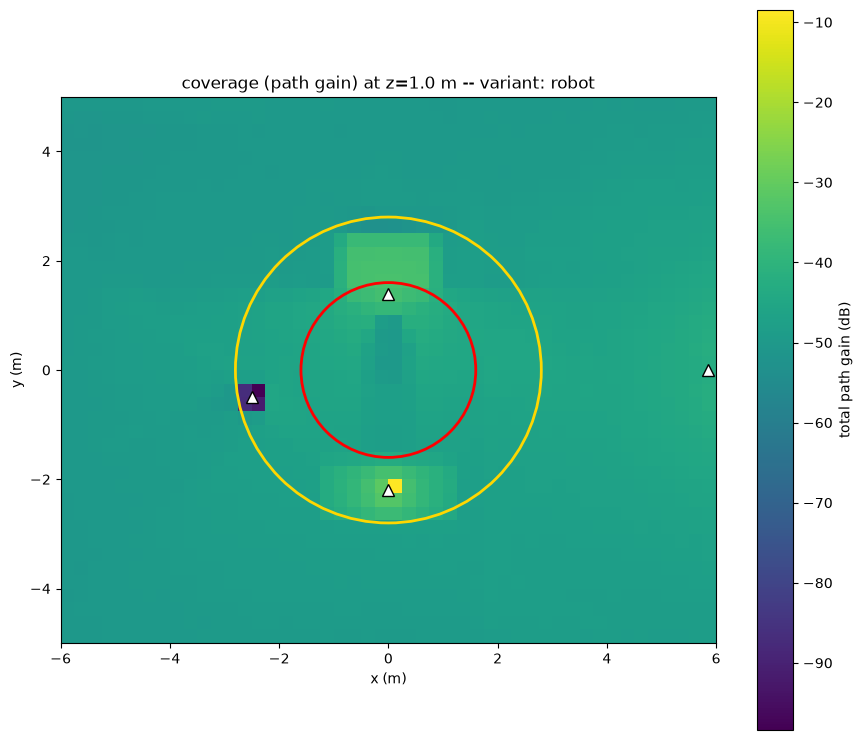

In [12]:
# --- CHECK 3: coverage map at human height, zones overlaid ---
# Run for VARIANT='robot' AND 'norobot' (change it in the FILES cell and
# re-run from there) to SEE the robot's shadow.
from sionna.rt import RadioMapSolver

room = cfg['room']
Z_H = 1.0   # measurement height (approx torso)
rm_solver = RadioMapSolver()
try:
    rmap = rm_solver(scene, max_depth=5, cell_size=(0.25, 0.25),
                     center=[0.0, 0.0, Z_H], size=[room['x'], room['y']],
                     orientation=[0.0, 0.0, 0.0])
    pg = np.array(rmap.path_gain)   # LINEAR path gain (NOT dB)
    print('path_gain shape:', pg.shape, '| min/max:', float(pg.min()), float(pg.max()))
    pg_lin = np.sum(pg, axis=0) if pg.ndim == 3 else pg   # combine TXs in linear
    pg_db = 10*np.log10(pg_lin + 1e-20)                   # -> dB for display
    ext = [-room['x']/2, room['x']/2, -room['y']/2, room['y']/2]
    fig, ax = plt.subplots(figsize=(9, 7.5))
    im = ax.imshow(pg_db, origin='lower', extent=ext, aspect='equal', cmap='viridis')
    plt.colorbar(im, ax=ax, label='total path gain (dB)')
    sz = cfg['safety_zones']; c = sz['center']
    for r, col in [(sz['red_radius'], 'red'), (sz['yellow_radius'], 'gold')]:
        ax.add_patch(plt.Circle((c[0], c[1]), r, fill=False, edgecolor=col, lw=2))
    for tx in cfg['suggested_tx']:
        ax.plot(tx['pos'][0], tx['pos'][1], '^', color='w', ms=9, mec='k')
    ax.set_title(f'coverage (path gain) at z={Z_H} m -- variant: {VARIANT}')
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
    plt.tight_layout(); plt.show()
except Exception as e:
    print('RadioMapSolver API differs in your build -- check center/size/cell_size')
    print('kwargs against Sionna 2.0.1 docs. error:', e)

## What to look for

- **Check 1:** 12 objects (robot variant) / 9 (norobot); materials read
  `concrete` (shell) and `metal` (ceiling + equipment). Render shows the
  cobot, CNC, cabinet, bench, pallet in a 12x10 m bay.
- **Check 2:** no NaNs, and no link buried tens of dB below the others
  (a fully-blocked TX). If one is dead, we move that equipment TX.
- **Check 3:** the red/yellow zones sit on well-lit floor (not a dead
  patch). Comparing `robot` vs `norobot`, the robot variant should show
  a visible shadow near/behind the metal cobot -- that shadow IS the
  coverage story we characterise later.

If coverage over the zones looks good, **step one is done** and we move
to **step two: the worker data-generation notebook** (place 0/1/2 rigid
dielectric bodies, trace CSI, label presence / count / zone).